In [1]:
from sklearn.datasets import make_classification
import numpy as np
X,y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2,
                          n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=20)

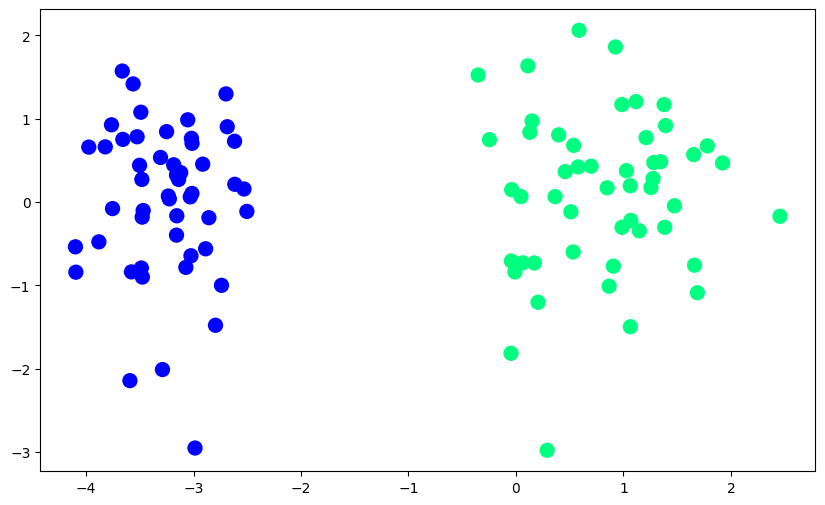

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

In [12]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None, solver='sag')
lor.fit(X,y)

/home/kali/miniconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [14]:
print(lor.coef_)
print(lor.intercept_)

[[4.80417456 0.19858479]]
[5.78974006]


In [16]:
m1 = -(lor.coef_[0][0] / lor.coef_[0][1])
b1 = -(lor.intercept_ / lor.coef_[0][1])

In [17]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [48]:
def gd(X,y):
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(13000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])

    return weights[0], weights[1:]

In [49]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [50]:
intercept_,coef_ = gd(X,y)

In [51]:
m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

In [52]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

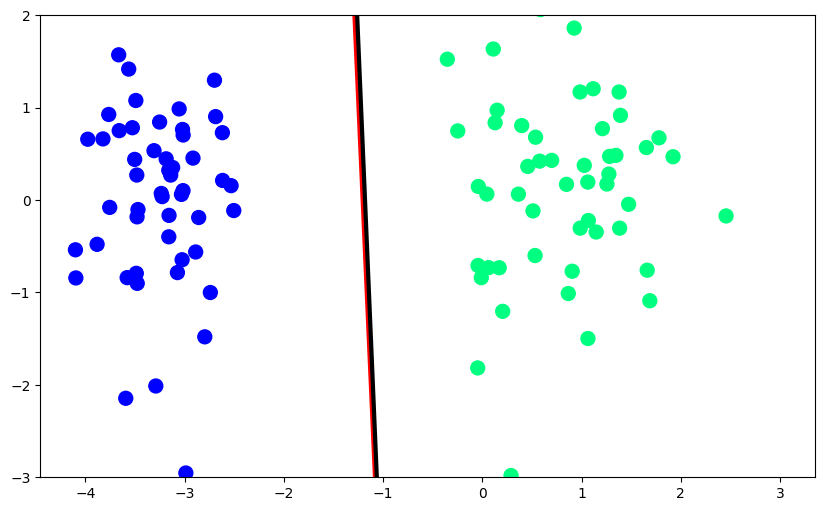

In [53]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.plot(x_input1, y_input1, color='black', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.ylim(-3,2)
plt.show()

- We are running it on 13000 epochs